# Kiểm định giả thuyết: ảnh hưởng đến `is_canceled`

Kiểm định 3 biến dự đoán với biến kết quả nhị phân `is_canceled`:

| Biến | Test chính | Effect size | Visualization |
|------|------------|-------------|---------------|
| `lead_time` | Mann-Whitney U | Rank-biserial *r* + bootstrap CI | Violin, KDE, bootstrap histogram |
| `lead_time` (bin) | Chi-squared | Cramér's V | Stacked bar, observed vs expected, residual heatmap |
| `deposit_type` | Chi-squared | Cramér's V | + post-hoc z-test bar chart |
| `market_segment` | Chi-squared | Cramér's V + standardized residuals | Stacked bar, residual heatmap |
| 3 biến đồng thời | Logistic regression | Odds ratio + Pseudo R² | Forest plot + đường xác suất hủy |

In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

ALPHA = 0.05
DATA_BASENAME = "hotel_bookings"
VERSION_PATTERN = re.compile(rf"^{DATA_BASENAME}_v(\d+)\.csv$", re.IGNORECASE)


def _data_search_roots() -> list[Path]:
    notebook_dir = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
    search_roots = [
        notebook_dir / "data",
        notebook_dir,
        notebook_dir.parent / "data",
        notebook_dir.parent,
        notebook_dir.parent.parent,
        Path.cwd() / "data",
        Path.cwd(),
    ]
    path = Path.cwd()
    for _ in range(6):
        search_roots.extend([path / "data", path])
        path = path.parent

    seen, roots = set(), []
    for root in search_roots:
        try:
            root = root.resolve()
        except OSError:
            continue
        if root not in seen:
            seen.add(root)
            roots.append(root)
    return roots


def find_latest_versioned_data_file() -> Path:
    candidates: list[tuple[int, Path]] = []
    for root in _data_search_roots():
        if not root.is_dir():
            continue
        for file_path in root.glob(f"{DATA_BASENAME}_v*.csv"):
            if "test" in file_path.name.lower():
                continue
            match = VERSION_PATTERN.match(file_path.name)
            if match:
                candidates.append((int(match.group(1)), file_path.resolve()))

    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy file '{DATA_BASENAME}_v*.csv'")

    latest_version, latest_path = max(candidates, key=lambda item: item[0])
    print(f"Chọn file v{latest_version} mới nhất: {latest_path.name}")
    return latest_path


csv_path = find_latest_versioned_data_file()
print(f"Đang đọc: {csv_path}")
df = pd.read_csv(
    csv_path,
    usecols=["lead_time", "is_canceled", "deposit_type", "market_segment"],
)
print(f"Số booking: {len(df):,}")
print(f"Tỷ lệ hủy: {df['is_canceled'].mean() * 100:.2f}%")
df.head()

Chọn file v5 mới nhất: hotel_bookings_v5.csv
Đang đọc: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
Số booking: 82,811
Tỷ lệ hủy: 28.12%


,is_canceled,lead_time,market_segment,deposit_type
0,0,342,Direct,No Deposit
1,0,737,Direct,No Deposit
2,0,7,Direct,No Deposit
3,0,13,Corporate,No Deposit
4,0,14,Online TA,No Deposit


In [2]:
def cramers_v(contingency: pd.DataFrame) -> float:
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    return float(np.sqrt(chi2 / (n * min(r - 1, k - 1))))


def rank_biserial_from_u(u_stat: float, n0: int, n1: int) -> float:
    """Effect size cho Mann-Whitney: nhóm 0 là mẫu đầu tiên."""
    return 1 - (2 * u_stat) / (n0 * n1)


def bootstrap_median_diff(
    group_a: np.ndarray,
    group_b: np.ndarray,
    n_boot: int = 5000,
    seed: int = 42,
    return_samples: bool = False,
) -> dict:
    """Bootstrap CI cho median(B) - median(A)."""
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        sample_a = rng.choice(group_a, size=len(group_a), replace=True)
        sample_b = rng.choice(group_b, size=len(group_b), replace=True)
        diffs[i] = np.median(sample_b) - np.median(sample_a)
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    out = {
        "median_diff": float(np.median(diffs)),
        "ci_low": float(lo),
        "ci_high": float(hi),
    }
    if return_samples:
        out["samples"] = diffs
    return out


_MPL_CHAR_MAP = str.maketrans({
    "₀": "0", "₁": "1", "₂": "2", "₃": "3",
    "⁰": "0", "¹": "1", "²": "2", "³": "3",
    "α": "a", "χ": "chi", "−": "-",
})


def _mpl_text(text: str) -> str:
    """Chuyen ky tu Unicode kho ve ASCII cho matplotlib (tranh loi font Arial)."""
    return text.translate(_MPL_CHAR_MAP)


def _format_p(p_value: float) -> str:
    if p_value <= 0 or p_value < 1e-300:
        return "p ~ 0"
    return f"p = {p_value:.2e}"


def _stats_textbox(ax, text: str, fontsize: int = 11) -> None:
    """Hien thi thong so thong ke trong text box (giong H1)."""
    ax.axis("off")
    ax.text(
        0.05,
        0.95,
        _mpl_text(text),
        va="top",
        fontsize=fontsize,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.4),
    )


def plot_mannwhitney_viz(
    df: pd.DataFrame,
    value_col: str,
    group_col: str,
    boot_samples: np.ndarray,
    test_result: dict,
    group_labels: list[str] | None = None,
) -> None:
    """Visualize Mann-Whitney U + bootstrap."""
    if group_labels is None:
        group_labels = ["Không hủy", "Đã hủy"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    plot_df = df[[group_col, value_col]].copy()
    plot_df["_group_label"] = plot_df[group_col].map(dict(zip([0, 1], group_labels)))
    sns.violinplot(
        data=plot_df, x="_group_label", y=value_col,
        order=group_labels, ax=axes[0, 0], inner="box",
    )
    axes[0, 0].set_xlabel("")
    axes[0, 0].set_title("Violin plot — phân bố lead_time")
    axes[0, 0].set_ylabel("Lead time (ngày)")

    sns.kdeplot(
        data=df, x=value_col, hue=group_col, hue_order=[0, 1],
        common_norm=False, ax=axes[0, 1], fill=True, alpha=0.35,
    )
    axes[0, 1].set_title("KDE — so sánh 2 nhóm")
    axes[0, 1].legend(title=group_col, labels=group_labels)

    axes[1, 0].hist(boot_samples, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    axes[1, 0].axvline(0, color="black", ls="--", lw=1)
    axes[1, 0].axvline(test_result["bootstrap_median_diff"]["ci_low"], color="red", ls="--", label="95% CI")
    axes[1, 0].axvline(test_result["bootstrap_median_diff"]["ci_high"], color="red", ls="--")
    axes[1, 0].axvline(test_result["bootstrap_median_diff"]["median_diff"], color="darkgreen", lw=2, label="Median diff")
    axes[1, 0].set_xlabel("Chênh median (hủy - không hủy, ngày)")
    axes[1, 0].set_ylabel("Tần suất bootstrap")
    axes[1, 0].set_title("Bootstrap distribution (Mann-Whitney)")
    axes[1, 0].legend()

    axes[1, 1].axis("off")
    txt = (
        f"Mann-Whitney U\n"
        f"  U = {test_result['u_stat']:.0f}\n"
        f"  {_format_p(test_result['p_value'])}\n"
        f"  rank-biserial r = {test_result['rank_biserial_r']:.4f}\n\n"
        f"Median lead_time\n"
        f"  Không hủy: {test_result['median_not_canceled']:.1f} ngày\n"
        f"  Đã hủy:    {test_result['median_canceled']:.1f} ngày\n\n"
        f"Bootstrap 95% CI\n"
        f"  [{test_result['bootstrap_median_diff']['ci_low']:.1f}, "
        f"{test_result['bootstrap_median_diff']['ci_high']:.1f}] ngày\n\n"
        f"Kết luận (α={ALPHA}):\n"
        f"  {'Bác bỏ H₀' if test_result['reject_h0'] else 'Không bác bỏ H₀'}"
    )
    _stats_textbox(axes[1, 1], txt)

    fig.suptitle("H1 — Mann-Whitney U: lead_time vs is_canceled", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_chi_square_viz(
    contingency: pd.DataFrame,
    test_result: dict,
    title: str,
    xlabel: str,
    category_order: list | None = None,
) -> None:
    """Visualize Chi-squared: stacked bar, observed vs expected, residual heatmap."""
    ct = contingency.copy()
    if category_order:
        ct = ct.reindex(category_order)

    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    resid = test_result["standardized_residuals"]
    if category_order is not None:
        resid = resid.reindex(category_order)

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    pct.plot(kind="bar", stacked=True, ax=axes[0, 0], color=["#66c2a5", "#fc8d62"], edgecolor="white")
    axes[0, 0].set_ylabel("Tỷ lệ (%)")
    axes[0, 0].set_xlabel(xlabel)
    axes[0, 0].set_title("Stacked 100% — tỷ lệ hủy / không hủy")
    axes[0, 0].legend(title="Trạng thái", bbox_to_anchor=(1.02, 1))
    axes[0, 0].tick_params(axis="x", rotation=30)

    x = np.arange(len(ct.index))
    width = 0.35
    axes[0, 1].bar(x - width / 2, ct["Không hủy"], width, label="Observed — Không hủy", color="#66c2a5")
    axes[0, 1].bar(x + width / 2, ct["Đã hủy"], width, label="Observed — Đã hủy", color="#fc8d62")
    exp = test_result["expected"].reindex(ct.index)
    axes[0, 1].scatter(x - width / 2, exp["Không hủy"], marker="x", color="black", s=80, zorder=5, label="Expected")
    axes[0, 1].scatter(x + width / 2, exp["Đã hủy"], marker="x", color="black", s=80, zorder=5)
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(ct.index, rotation=30, ha="right")
    axes[0, 1].set_ylabel("Số booking")
    axes[0, 1].set_title("Observed (cột) vs Expected (×)")
    axes[0, 1].legend(fontsize=8)

    sns.heatmap(
        resid, annot=True, fmt=".1f", cmap="RdBu_r", center=0, vmin=-4, vmax=4,
        ax=axes[1, 0], cbar_kws={"label": "Std. residual"},
    )
    axes[1, 0].set_title("Standardized residuals\n(|r| > 2 = đóng góp bất thường)")

    reject = test_result.get("reject_h0", test_result["p_value"] < ALPHA)
    stats_txt = (
        f"Chi-squared test\n"
        f"  chi2 = {test_result['chi2']:.2f}\n"
        f"  df = {test_result['dof']}\n"
        f"  {_format_p(test_result['p_value'])}\n"
        f"  Cramér's V = {test_result['cramers_v']:.4f}\n\n"
        f"Kiểm tra giả định\n"
        f"  min expected = {test_result['min_expected']:.2f}\n"
        f"  ô expected < 5: {test_result['cells_expected_lt_5']}\n\n"
        f"Kết luận (α={ALPHA}):\n"
        f"  {'Bác bỏ H₀' if reject else 'Không bác bỏ H₀'}"
    )
    if "fisher_exact_p" in test_result:
        stats_txt += (
            f"\n\nFisher's exact (2x2)\n"
            f"  {_format_p(test_result['fisher_exact_p'])}\n"
            f"  OR = {test_result['odds_ratio']:.4f}"
        )
    _stats_textbox(axes[1, 1], stats_txt)

    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_pairwise_ztest(pairwise_df: pd.DataFrame, title: str) -> None:
    """Visualize z-test post-hoc: chênh tỷ lệ hủy giữa các cặp."""
    if pairwise_df.empty:
        return

    plot_df = pairwise_df.copy()
    plot_df["pair"] = plot_df["group_a"] + " vs " + plot_df["group_b"]
    plot_df["diff_%"] = plot_df["cancel_rate_a_%"] - plot_df["cancel_rate_b_%"]
    plot_df = plot_df.sort_values("diff_%")

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(plot_df) * 0.7)),
                             gridspec_kw={"width_ratios": [1.6, 1]})

    colors = ["#d62728" if p < ALPHA else "#7f7f7f" for p in plot_df["p_bonferroni"]]
    axes[0].barh(plot_df["pair"], plot_df["diff_%"], color=colors, edgecolor="white")
    axes[0].axvline(0, color="black", lw=0.8)
    axes[0].set_xlabel("Chênh tỷ lệ hủy (%, group_a - group_b)")
    axes[0].set_title(f"{title}\nĐỏ = Bonferroni p < {ALPHA}")

    lines = ["Post-hoc z-test\n"]
    for _, row in plot_df.iterrows():
        sig = "*" if row["p_bonferroni"] < ALPHA else ""
        lines.append(f"{row['pair']}{sig}")
        lines.append(f"  rate A: {row['cancel_rate_a_%']:.1f}%")
        lines.append(f"  rate B: {row['cancel_rate_b_%']:.1f}%")
        lines.append(f"  z = {row['z_stat']:.3f}")
        lines.append(f"  {_format_p(row['p_value'])}")
        lines.append(f"  Bonferroni: {_format_p(row['p_bonferroni'])}")
        lines.append("")
    lines.append(f"α = {ALPHA}  (* = có ý nghĩa)")
    _stats_textbox(axes[1], "\n".join(lines), fontsize=10)

    plt.tight_layout()
    plt.show()


def plot_logistic_viz(
    logit,
    or_table: pd.DataFrame,
    model_df: pd.DataFrame,
    test_result: dict | None = None,
    lead_time_or_30d: float | None = None,
) -> None:
    """Forest plot OR + predicted probability + thong so thong ke."""
    import statsmodels.api as sm

    n_terms = len(or_table[or_table.index != "const"])
    fig, axes = plt.subplots(
        1, 3, figsize=(22, max(6, n_terms * 0.35)),
        gridspec_kw={"width_ratios": [1.3, 1.1, 0.9]},
    )

    plot_or = or_table.reset_index(names="term").copy()
    plot_or = plot_or[plot_or["term"] != "const"].sort_values("odds_ratio")
    sig = plot_or["p_value"] < ALPHA
    colors = np.where(sig, "#d62728", "#7f7f7f")

    y_pos = np.arange(len(plot_or))
    axes[0].errorbar(
        plot_or["odds_ratio"], y_pos,
        xerr=[plot_or["odds_ratio"] - plot_or["or_ci_low"], plot_or["or_ci_high"] - plot_or["odds_ratio"]],
        fmt="o", capsize=4, color="steelblue",
    )
    axes[0].scatter(plot_or["odds_ratio"], y_pos, c=colors, s=80, zorder=5)
    axes[0].axvline(1.0, ls="--", color="gray")
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(plot_or["term"])
    axes[0].set_xlabel("Odds ratio (95% CI)")
    axes[0].set_title("Forest plot\nĐỏ = p < 0.05")

    lt_range = np.linspace(0, model_df["lead_time"].quantile(0.99), 100)
    X_cat = pd.get_dummies(model_df[["deposit_type", "market_segment"]], drop_first=True)
    X_design = pd.concat([model_df[["lead_time"]], X_cat], axis=1).astype(float)
    X_design = sm.add_constant(X_design)
    mask = (model_df["deposit_type"] == "No Deposit") & (model_df["market_segment"] == "Direct")
    ref_idx = model_df[mask].index[0] if mask.any() else model_df.index[0]
    pred_X = pd.concat([X_design.loc[[ref_idx]]] * len(lt_range), ignore_index=True)
    pred_X["lead_time"] = lt_range
    pred_X = pred_X[logit.model.exog_names]
    prob = logit.predict(pred_X)
    axes[1].plot(lt_range, prob * 100, color="steelblue", lw=2)
    axes[1].set_xlabel("Lead time (ngày)")
    axes[1].set_ylabel("Xác suất hủy dự đoán (%)")
    subtitle = f"OR +30 ngày = {lead_time_or_30d:.3f}" if lead_time_or_30d else ""
    axes[1].set_title(f"Đường dự đoán (baseline cố định)\n{subtitle}")
    axes[1].grid(alpha=0.3)

    lines = [
        "Logistic regression",
        f"  n = {int(logit.nobs):,}",
        f"  Pseudo R² = {logit.prsquared:.4f}",
        "",
    ]
    if test_result:
        lines.extend([
            "LR test (vs null)",
            f"  chi2 = {test_result['lr_chi2']:.2f}",
            f"  df = {test_result['lr_df']}",
            f"  {_format_p(test_result['lr_p_value'])}",
            "",
        ])
    if "lead_time" in logit.params.index:
        lt_or = np.exp(logit.params["lead_time"])
        lines.extend([
            "lead_time",
            f"  OR (+1 ngày) = {lt_or:.4f}",
            f"  {_format_p(logit.pvalues['lead_time'])}",
        ])
        if lead_time_or_30d:
            lines.append(f"  OR (+30 ngày) = {lead_time_or_30d:.4f}")
        lines.append("")

    sig_terms = plot_or[plot_or["p_value"] < ALPHA]
    lines.append(f"Biến có ý nghĩa (α={ALPHA}):")
    if sig_terms.empty:
        lines.append("  (không có)")
    else:
        for _, row in sig_terms.iterrows():
            lines.append(f"  {row['term']}")
            lines.append(f"    OR = {row['odds_ratio']:.3f}, {_format_p(row['p_value'])}")

    lr_p = test_result["lr_p_value"] if test_result else 0
    lines.extend([
        "",
        f"Kết luận mô hình (α={ALPHA}):",
        f"  {'Bác bỏ H₀' if lr_p < ALPHA else 'Không bác bỏ H₀'}",
    ])
    _stats_textbox(axes[2], "\n".join(lines), fontsize=10)

    fig.suptitle("H4 — Logistic regression đa biến", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def chi_square_report(
    contingency: pd.DataFrame,
    variable_name: str,
    use_fisher_if_small: bool = True,
) -> dict:
    """Chạy chi-square, kiểm tra expected counts, báo cáo Cramér's V."""
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    expected_df = pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns,
    )
    min_expected = expected.min()
    small_cells = int((expected < 5).sum())

    result = {
        "variable": variable_name,
        "test": "chi2_contingency",
        "chi2": float(chi2),
        "dof": int(dof),
        "p_value": float(p_value),
        "cramers_v": cramers_v(contingency),
        "min_expected": float(min_expected),
        "cells_expected_lt_5": small_cells,
        "reject_h0": p_value < ALPHA,
    }

    if use_fisher_if_small and small_cells > 0 and contingency.shape == (2, 2):
        odds_ratio, fisher_p = stats.fisher_exact(contingency.to_numpy())
        result["fisher_exact_p"] = float(fisher_p)
        result["odds_ratio"] = float(odds_ratio)
        result["test"] = "fisher_exact_2x2"

    observed = contingency.to_numpy()
    residuals = (observed - expected) / np.sqrt(expected)
    result["standardized_residuals"] = pd.DataFrame(
        residuals,
        index=contingency.index,
        columns=contingency.columns,
    )
    result["expected"] = expected_df
    return result


def print_test_result(title: str, result: dict) -> None:
    print("=" * 60)
    print(title)
    print("=" * 60)
    for key in ["test", "statistic", "chi2", "u_stat", "dof", "p_value", "cramers_v", "reject_h0"]:
        if key in result:
            val = result[key]
            if isinstance(val, float):
                print(f"  {key}: {val:.6g}")
            else:
                print(f"  {key}: {val}")
    if "fisher_exact_p" in result:
        print(f"  fisher_exact_p: {result['fisher_exact_p']:.6g}")
    if "odds_ratio" in result:
        print(f"  odds_ratio: {result['odds_ratio']:.6g}")
    if "cells_expected_lt_5" in result:
        print(f"  cells_expected_lt_5: {result['cells_expected_lt_5']}")
        print(f"  min_expected: {result['min_expected']:.4f}")

## H1: `lead_time` ảnh hưởng `is_canceled`?

**H₀:** Phân bố `lead_time` giống nhau giữa booking hủy và không hủy.

**H₁:** Hai phân bố khác nhau.

**Test:** Mann-Whitney U (không giả định phân phối chuẩn) + bootstrap CI cho chênh median.

H1 — lead_time vs is_canceled (Mann-Whitney U)
  test: mannwhitneyu
  u_stat: 4.85465e+08
  p_value: 0
  reject_h0: True
  rank_biserial_r: 0.2995
  median không hủy: 37.0 ngày
  median đã hủy:   79.0 ngày
  bootstrap median diff (hủy - không hủy): 42.0 ngày [41.0, 44.0]
  t-test p-value (tham khảo): 0.00e+00


,is_canceled,n,median_lead_time,mean_lead_time
0,Không hủy (0),59527,37.0,68.176794
1,Đã hủy (1),23284,79.0,104.862824


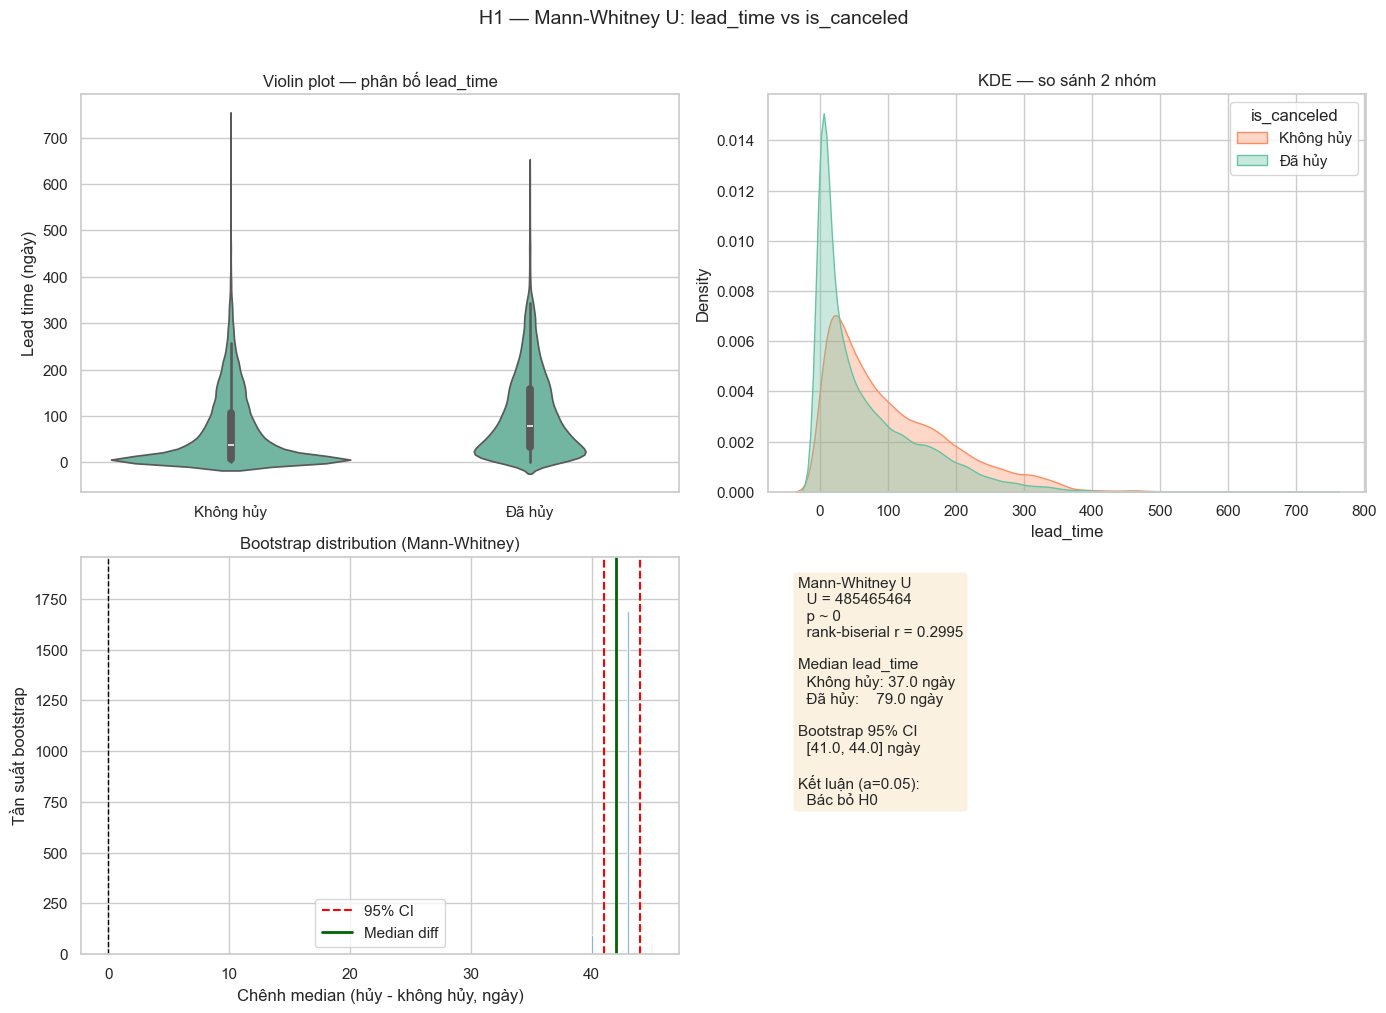

In [3]:
lead_not_canceled = df.loc[df["is_canceled"] == 0, "lead_time"].to_numpy()
lead_canceled = df.loc[df["is_canceled"] == 1, "lead_time"].to_numpy()

u_stat, p_mw = stats.mannwhitneyu(
    lead_not_canceled,
    lead_canceled,
    alternative="two-sided",
)

n0, n1 = len(lead_not_canceled), len(lead_canceled)
rbiserial = rank_biserial_from_u(u_stat, n0, n1)
boot = bootstrap_median_diff(lead_not_canceled, lead_canceled, return_samples=True)
boot_samples = boot.pop("samples")

# t-test bổ sung (so sánh mean — tham khảo)
t_stat, p_ttest = stats.ttest_ind(lead_canceled, lead_not_canceled, equal_var=False)

h1_result = {
    "variable": "lead_time",
    "test": "mannwhitneyu",
    "u_stat": float(u_stat),
    "p_value": float(p_mw),
    "rank_biserial_r": float(rbiserial),
    "median_not_canceled": float(np.median(lead_not_canceled)),
    "median_canceled": float(np.median(lead_canceled)),
    "mean_not_canceled": float(lead_not_canceled.mean()),
    "mean_canceled": float(lead_canceled.mean()),
    "bootstrap_median_diff": boot,
    "ttest_p_value": float(p_ttest),
    "reject_h0": p_mw < ALPHA,
}

print_test_result("H1 — lead_time vs is_canceled (Mann-Whitney U)", h1_result)
print(f"  rank_biserial_r: {rbiserial:.4f}")
print(f"  median không hủy: {h1_result['median_not_canceled']:.1f} ngày")
print(f"  median đã hủy:   {h1_result['median_canceled']:.1f} ngày")
print(
    f"  bootstrap median diff (hủy - không hủy): "
    f"{boot['median_diff']:.1f} ngày "
    f"[{boot['ci_low']:.1f}, {boot['ci_high']:.1f}]"
)
print(f"  t-test p-value (tham khảo): {p_ttest:.2e}")

summary_h1 = pd.DataFrame(
    {
        "is_canceled": ["Không hủy (0)", "Đã hủy (1)"],
        "n": [n0, n1],
        "median_lead_time": [h1_result["median_not_canceled"], h1_result["median_canceled"]],
        "mean_lead_time": [h1_result["mean_not_canceled"], h1_result["mean_canceled"]],
    }
)
display(summary_h1)

plot_mannwhitney_viz(df, "lead_time", "is_canceled", boot_samples, h1_result)

## H2: `deposit_type` ảnh hưởng `is_canceled`?

**H₀:** `deposit_type` và `is_canceled` độc lập.

**H₁:** Có association giữa loại cọc và tỷ lệ hủy.

**Test:** Chi-squared trên bảng contingency; Fisher's exact cho cặp 2×2 khi ô nhỏ.

H2 — deposit_type vs is_canceled (Chi-squared)
  test: chi2_contingency
  chi2: 2157.51
  dof: 2
  p_value: 0
  cramers_v: 0.161411
  reject_h0: True
  cells_expected_lt_5: 0
  min_expected: 22.7748


,n,cancel_rate,cancel_pct
deposit_type,,,
Non Refund,963,0.950156,95.015576
Refundable,81,0.283951,28.395062
No Deposit,81767,0.273289,27.328874


,Không hủy,Đã hủy
deposit_type,,
No Deposit,59421,22346
Non Refund,48,915
Refundable,58,23


,Không hủy,Đã hủy
deposit_type,,
No Deposit,58776.54,22990.46
Non Refund,692.23,270.77
Refundable,58.23,22.77


,Không hủy,Đã hủy
deposit_type,,
No Deposit,2.66,-4.25
Non Refund,-24.49,39.15
Refundable,-0.03,0.05



Post-hoc pairwise (z-test tỷ lệ hủy, Bonferroni):


,group_a,group_b,cancel_rate_a_%,cancel_rate_b_%,z_stat,p_value,fisher_p,odds_ratio,p_bonferroni
0,No Deposit,Refundable,27.3289,28.3951,-0.2152,0.8296,0.804,1.0545,1.0
1,No Deposit,Non Refund,27.3289,95.0156,-46.4491,0.0000,0.000,50.6897,0.0
2,Refundable,Non Refund,95.0156,28.3951,19.0660,0.0000,0.000,0.0208,0.0


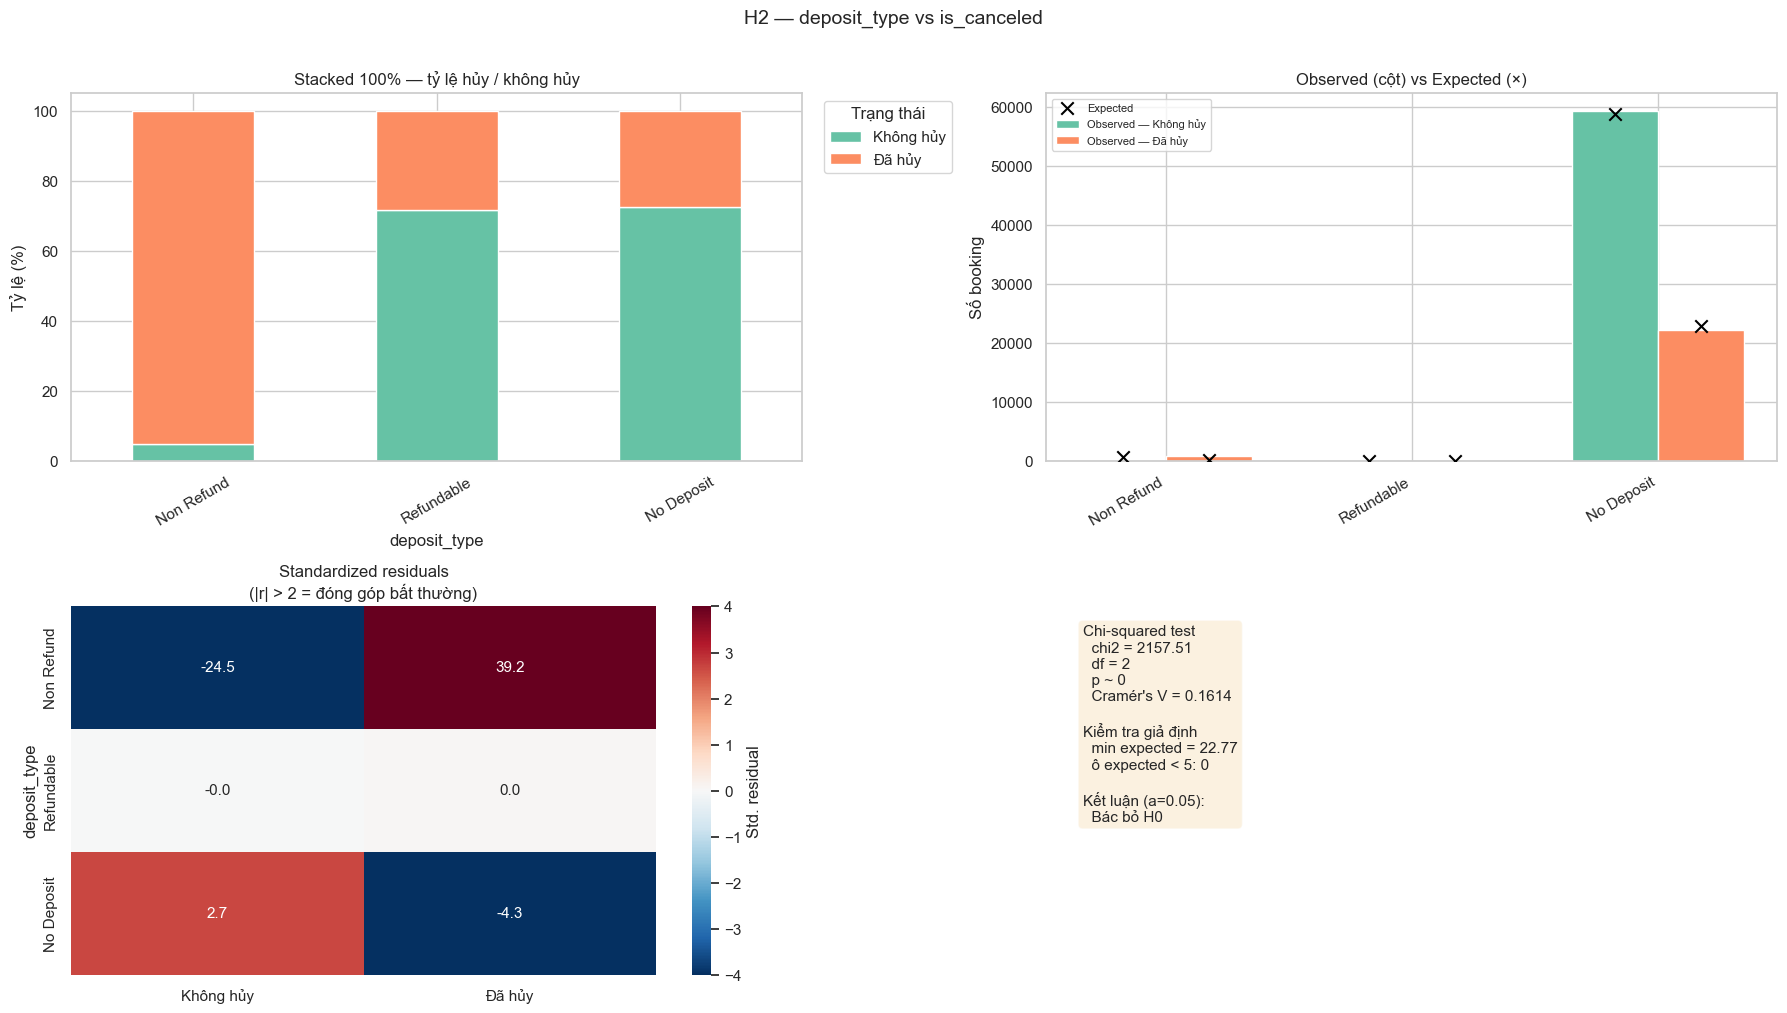

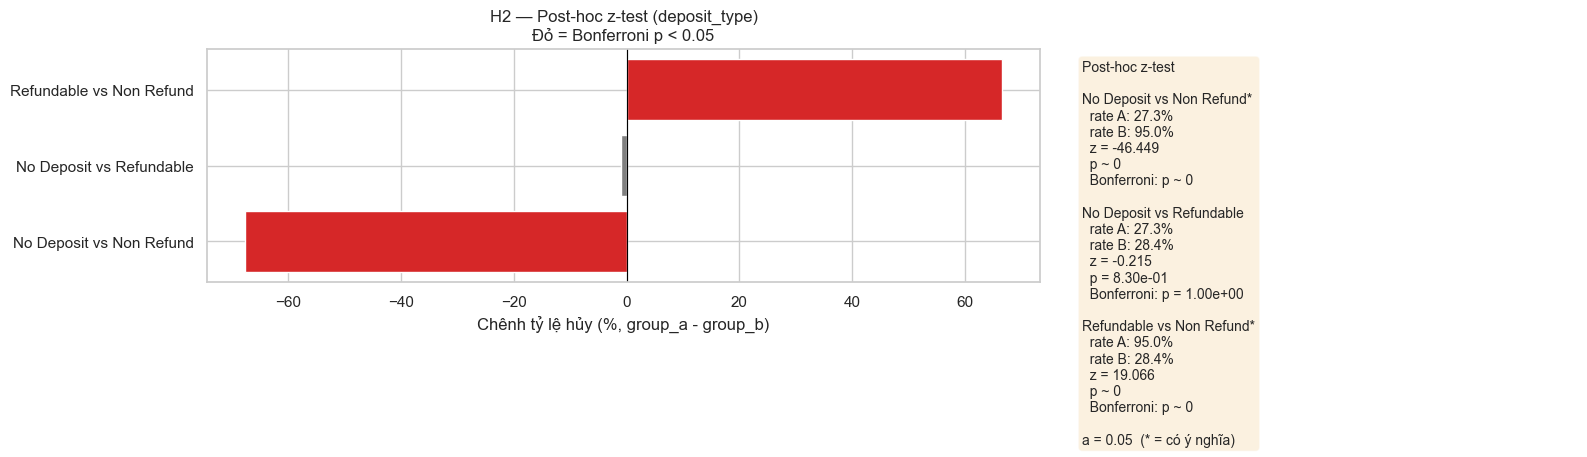

In [4]:
ct_deposit = pd.crosstab(df["deposit_type"], df["is_canceled"])
ct_deposit.columns = ["Không hủy", "Đã hủy"]

h2_result = chi_square_report(ct_deposit, "deposit_type")
print_test_result("H2 — deposit_type vs is_canceled (Chi-squared)", h2_result)

cancel_rate_deposit = (
    df.groupby("deposit_type", observed=True)["is_canceled"]
    .agg(n="count", cancel_rate="mean")
    .assign(cancel_pct=lambda x: x["cancel_rate"] * 100)
    .sort_values("cancel_pct", ascending=False)
)
display(cancel_rate_deposit)
display(ct_deposit)
display(h2_result["expected"].round(2))
display(h2_result["standardized_residuals"].round(2))

# Post-hoc: z-test 2 tỷ lệ cho từng cặp deposit_type
deposit_types = df["deposit_type"].unique()
pairwise_rows = []
for i, a in enumerate(deposit_types):
    for b in deposit_types[i + 1 :]:
        sub = df[df["deposit_type"].isin([a, b])]
        ct_pair = pd.crosstab(sub["deposit_type"], sub["is_canceled"])
        if ct_pair.shape != (2, 2):
            continue
        count = ct_pair.to_numpy()
        # two-proportion z-test
        p1 = count[0, 1] / count[0].sum()
        p2 = count[1, 1] / count[1].sum()
        n1, n2 = count[0].sum(), count[1].sum()
        p_pool = (count[0, 1] + count[1, 1]) / (n1 + n2)
        se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
        z = (p1 - p2) / se if se > 0 else 0.0
        p_pair = 2 * (1 - stats.norm.cdf(abs(z)))
        fisher_or, fisher_p = stats.fisher_exact(count)
        pairwise_rows.append(
            {
                "group_a": a,
                "group_b": b,
                "cancel_rate_a_%": p1 * 100,
                "cancel_rate_b_%": p2 * 100,
                "z_stat": z,
                "p_value": p_pair,
                "fisher_p": fisher_p,
                "odds_ratio": fisher_or,
            }
        )

pairwise_deposit = pd.DataFrame(pairwise_rows)
if not pairwise_deposit.empty:
    n_pairs = len(pairwise_deposit)
    pairwise_deposit["p_bonferroni"] = np.minimum(pairwise_deposit["p_value"] * n_pairs, 1.0)
    print("\nPost-hoc pairwise (z-test tỷ lệ hủy, Bonferroni):")
    display(pairwise_deposit.round(4))

plot_chi_square_viz(
    ct_deposit, h2_result,
    title="H2 — deposit_type vs is_canceled",
    xlabel="deposit_type",
    category_order=cancel_rate_deposit.index.tolist(),
)

if not pairwise_deposit.empty:
    plot_pairwise_ztest(pairwise_deposit, "H2 — Post-hoc z-test (deposit_type)")

## H3: `market_segment` ảnh hưởng `is_canceled`?

**H₀:** `market_segment` và `is_canceled` độc lập.

**H₁:** Có association giữa phân khúc thị trường và tỷ lệ hủy.

**Test:** Chi-squared + phân tích standardized residuals (|r| > 2 ≈ đóng góp bất thường).

H3 — market_segment vs is_canceled (Chi-squared)
  test: chi2_contingency
  chi2: 3960.39
  dof: 7
  p_value: 0
  cramers_v: 0.218688
  reject_h0: True
  cells_expected_lt_5: 2
  min_expected: 0.5623


,n,cancel_rate,cancel_pct
market_segment,,,
Undefined,2,1.000000,100.000000
Online TA,50391,0.355341,35.534123
Groups,3690,0.311924,31.192412
Aviation,220,0.190909,19.090909
Offline TA/TO,12860,0.150622,15.062208
Direct,11351,0.149150,14.914985
Complementary,619,0.130856,13.085622
Corporate,3678,0.128331,12.833061


,Không hủy,Đã hủy
market_segment,,
Aviation,178,42
Complementary,538,81
Corporate,3206,472
Direct,9658,1693
Groups,2539,1151
Offline TA/TO,10923,1937
Online TA,32485,17906
Undefined,0,2


,Không hủy,Đã hủy
market_segment,,
Aviation,1.58,-2.52
Complementary,4.41,-7.05
Corporate,10.93,-17.48
Direct,16.59,-26.53
Groups,-2.20,3.52
Offline TA/TO,17.46,-27.92
Online TA,-19.64,31.40
Undefined,-1.20,1.92



Standardized residuals |r| > 2:


,segment,column,std_residual
12,Online TA,Đã hủy,31.400
10,Offline TA/TO,Đã hủy,-27.919
6,Direct,Đã hủy,-26.526
11,Online TA,Không hủy,-19.638
4,Corporate,Đã hủy,-17.481
9,Offline TA/TO,Không hủy,17.461
5,Direct,Không hủy,16.590
3,Corporate,Không hủy,10.933
2,Complementary,Đã hủy,-7.053
1,Complementary,Không hủy,4.411


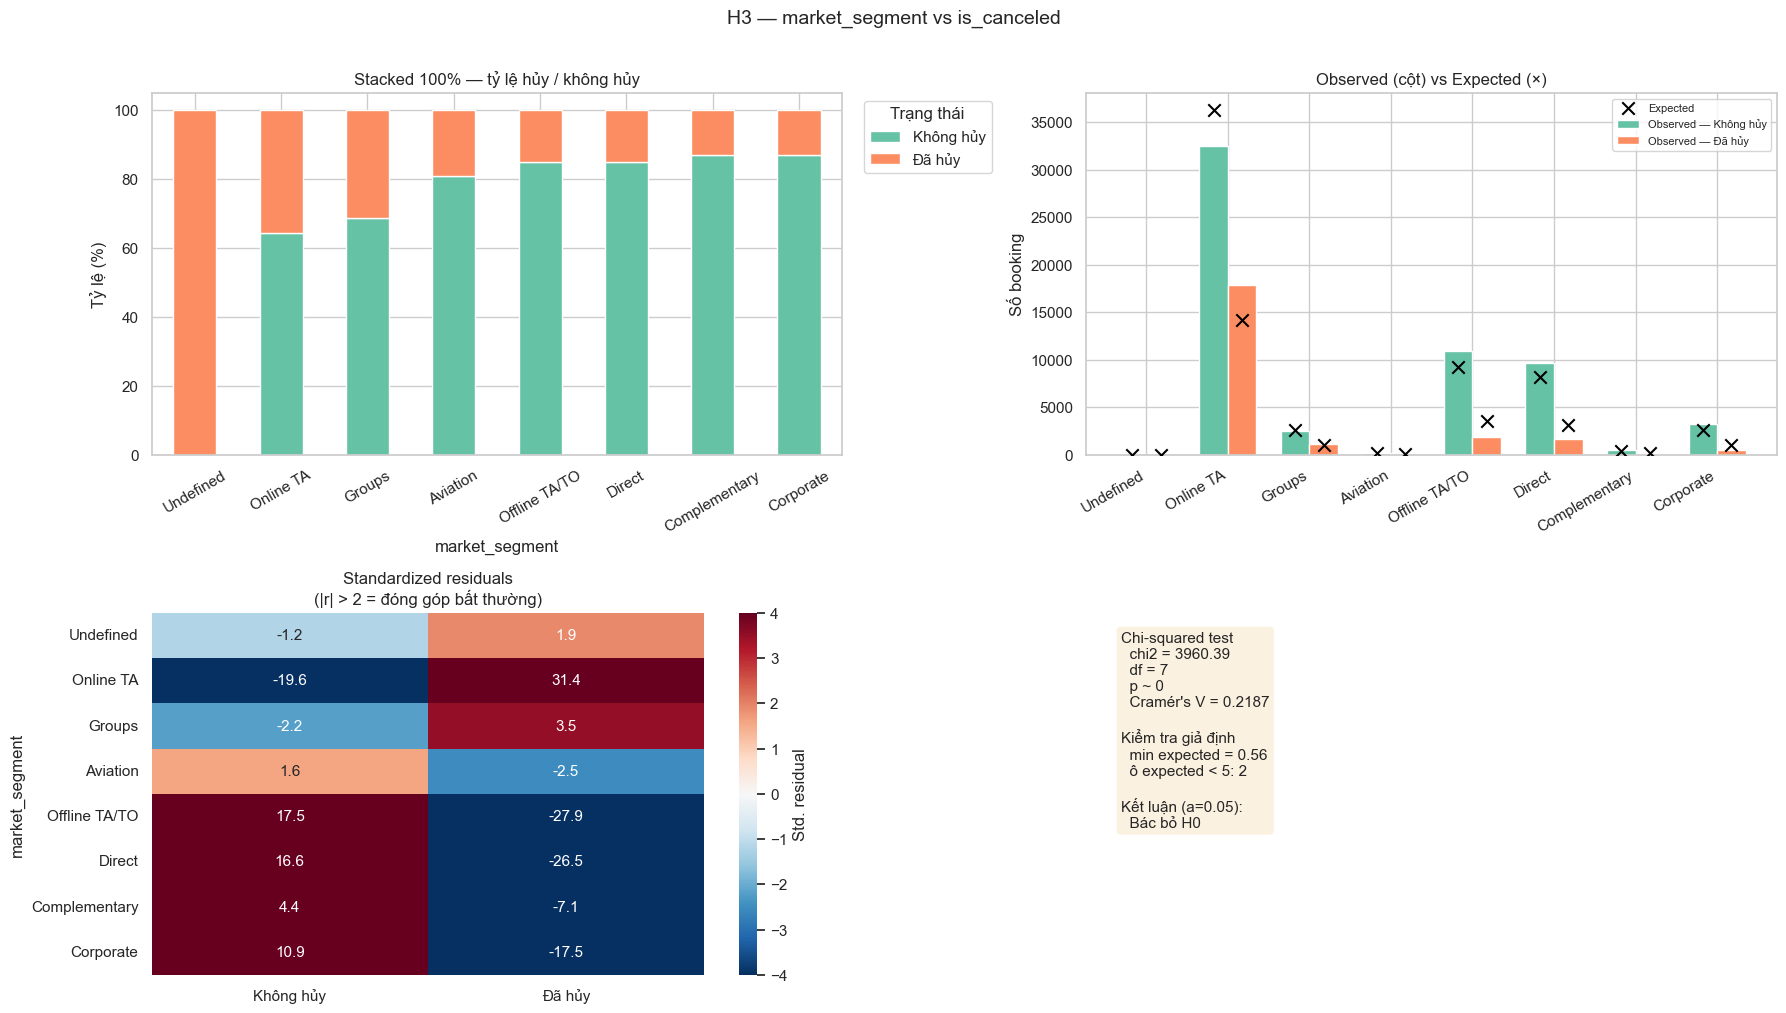

In [5]:
ct_segment = pd.crosstab(df["market_segment"], df["is_canceled"])
ct_segment.columns = ["Không hủy", "Đã hủy"]

h3_result = chi_square_report(ct_segment, "market_segment")
print_test_result("H3 — market_segment vs is_canceled (Chi-squared)", h3_result)

cancel_rate_segment = (
    df.groupby("market_segment", observed=True)["is_canceled"]
    .agg(n="count", cancel_rate="mean")
    .assign(cancel_pct=lambda x: x["cancel_rate"] * 100)
    .sort_values("cancel_pct", ascending=False)
)
display(cancel_rate_segment)
display(ct_segment)
display(h3_result["standardized_residuals"].round(2))

# Segment có residual |z| > 2 — đóng góp bất thường vào chi-square
resid = h3_result["standardized_residuals"]
notable = []
for idx in resid.index:
    for col in resid.columns:
        val = resid.loc[idx, col]
        if abs(val) > 2:
            notable.append({"segment": idx, "column": col, "std_residual": val})
notable_df = pd.DataFrame(notable).sort_values("std_residual", key=abs, ascending=False)
if not notable_df.empty:
    print("\nStandardized residuals |r| > 2:")
    display(notable_df.round(3))

plot_chi_square_viz(
    ct_segment, h3_result,
    title="H3 — market_segment vs is_canceled",
    xlabel="market_segment",
    category_order=cancel_rate_segment.index.tolist(),
)

## H1b: `lead_time` (theo bin) ảnh hưởng `is_canceled`?

**H₀:** Nhóm lead_time bin và `is_canceled` độc lập.

**H₁:** Tỷ lệ hủy khác nhau giữa các bin lead_time.

**Test:** Chi-squared trên bảng `lead_time_bin × is_canceled` (cùng bin như EDA: 0–30, 31–60, 61–90, 91–180, >180 ngày).

H1b — lead_time_bin vs is_canceled (Chi-squared)
  test: chi2_contingency
  chi2: 3763.96
  dof: 4
  p_value: 0
  cramers_v: 0.213196
  reject_h0: True
  cells_expected_lt_5: 0
  min_expected: 2521.2548


,n,cancel_rate,cancel_pct
lead_time_bin,,,
0-30,33039,0.17,16.83
31-60,12776,0.32,32.21
61-90,8967,0.33,33.21
91-180,17355,0.36,35.60
>180,10674,0.42,41.73


,Không hủy,Đã hủy
lead_time_bin,,
0-30,27480,5559
31-60,8661,4115
61-90,5989,2978
91-180,11177,6178
>180,6220,4454


,Không hủy,Đã hủy
lead_time_bin,,
0-30,24.21,-38.71
31-60,-5.46,8.72
61-90,-5.69,9.10
91-180,-11.62,18.59
>180,-16.59,26.52


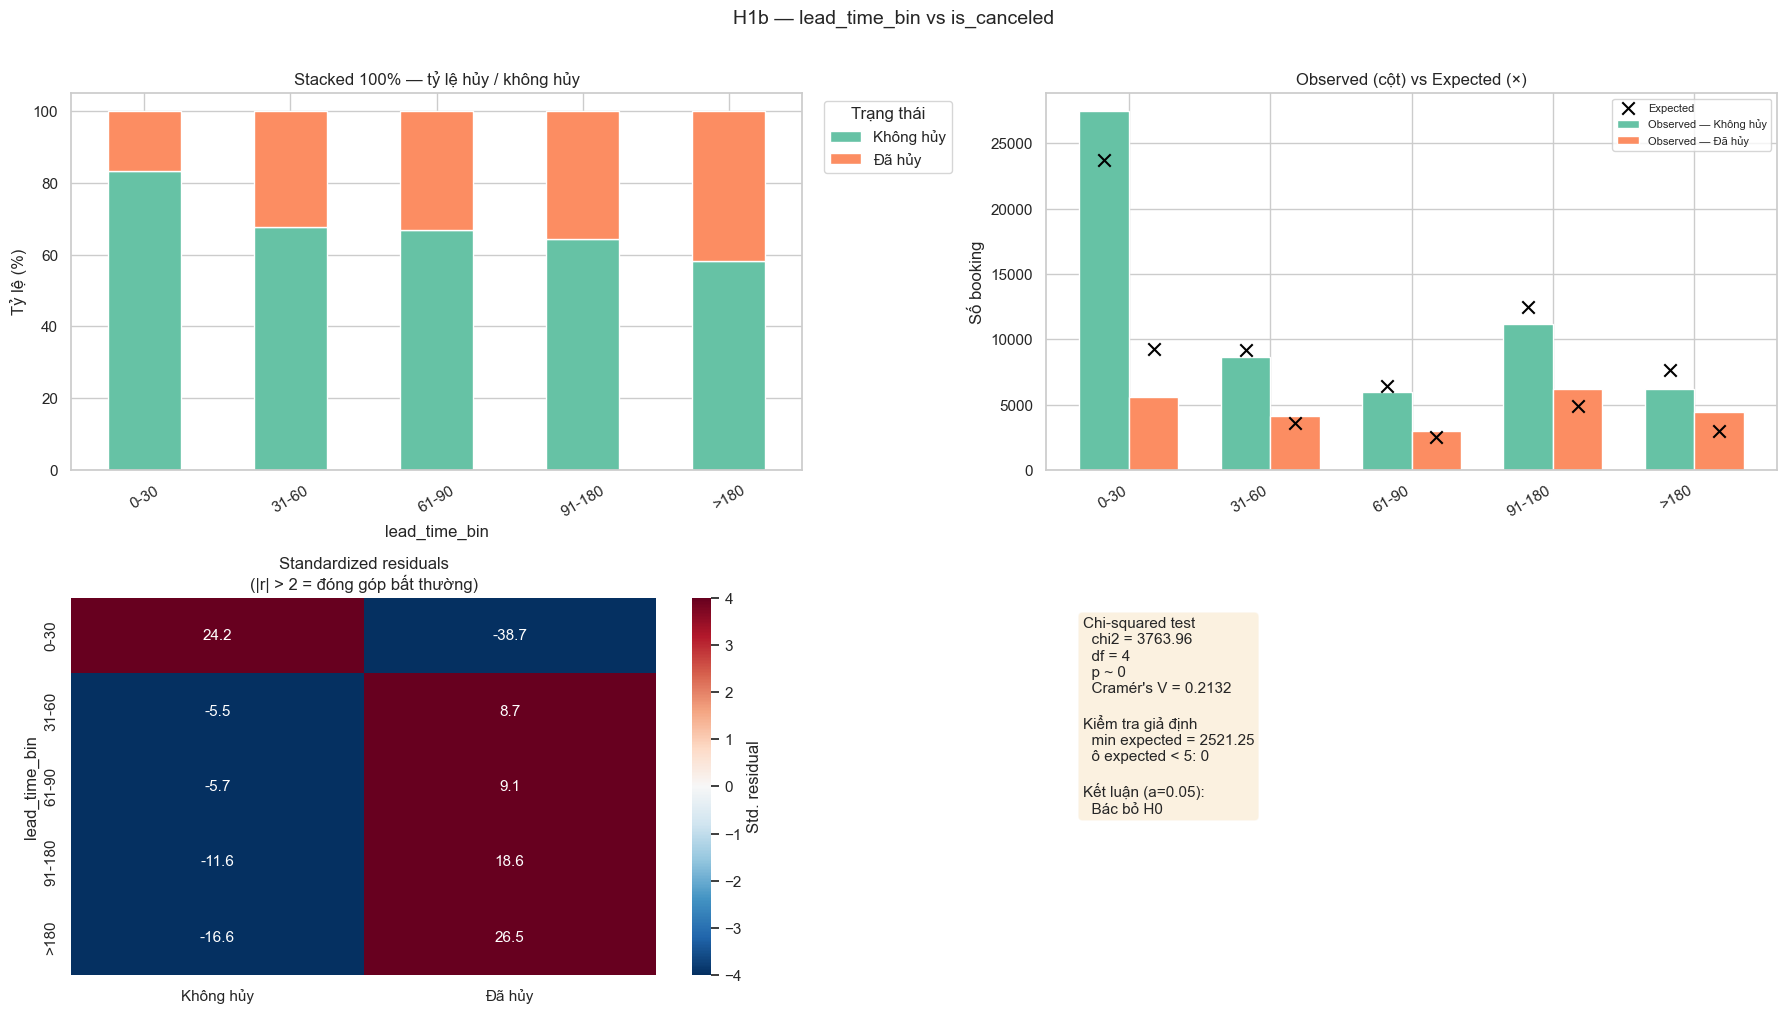

In [6]:
BIN_LABELS = ["0-30", "31-60", "61-90", "91-180", ">180"]
BIN_EDGES = [0, 30, 60, 90, 180, df["lead_time"].max() + 1]

df["lead_time_bin"] = pd.cut(
    df["lead_time"],
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=True,
    include_lowest=True,
)

ct_lead_bin = pd.crosstab(df["lead_time_bin"], df["is_canceled"])
ct_lead_bin.columns = ["Không hủy", "Đã hủy"]

h1b_result = chi_square_report(ct_lead_bin, "lead_time_bin")
print_test_result("H1b — lead_time_bin vs is_canceled (Chi-squared)", h1b_result)

cancel_rate_lead = (
    df.groupby("lead_time_bin", observed=True)["is_canceled"]
    .agg(n="count", cancel_rate="mean")
    .assign(cancel_pct=lambda x: x["cancel_rate"] * 100)
    .reindex(BIN_LABELS)
)
display(cancel_rate_lead.round(2))
display(ct_lead_bin)
display(h1b_result["standardized_residuals"].round(2))

plot_chi_square_viz(
    ct_lead_bin, h1b_result,
    title="H1b — lead_time_bin vs is_canceled",
    xlabel="lead_time_bin",
    category_order=BIN_LABELS,
)

## H4: Mô hình Logistic Regression đa biến

Kiểm định đồng thời 3 biến trong một mô hình:

`is_canceled ~ lead_time + deposit_type + market_segment`

- **H₀ (từng hệ số):** Biến không ảnh hưởng đến log-odds hủy khi đã kiểm soát các biến còn lại.
- **Odds ratio (OR):** OR > 1 → tăng xác suất hủy; OR < 1 → giảm xác suất hủy.
- Baseline phân loại: `deposit_type = No Deposit`, `market_segment = Direct`.
- `lead_time`: hệ số liên tục — OR = exp(β) cho mỗi +1 ngày đặt trước.

C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:                82811
Model:                          Logit   Df Residuals:                    82800
Method:                           MLE   Df Model:                           10
Date:                Sun, 05 Jul 2026   Pseudo R-squ.:                 0.09369
Time:                        09:35:53   Log-Likelihood:                -44585.
converged:                       True   LL-Null:                       -49194.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -1.6705      0.183     -9.108      0.000      -2.030      -1.311
lead_time                        0.0049   9.94e-05     48.944      0.000     

,coef,std_err,z,p_value,odds_ratio,or_ci_low,or_ci_high
lead_time,0.0049,0.0001,48.9441,0.0000,1.0049,1.0047,1.0051
deposit_type_Non Refund,4.3811,0.1545,28.3489,0.0000,79.9272,59.0402,108.2035
market_segment_Offline TA/TO,-0.7708,0.1858,-4.1495,0.0000,0.4627,0.3215,0.6658
market_segment_Online TA,0.6718,0.1838,3.6546,0.0003,1.9578,1.3655,2.8069
market_segment_Groups,-0.5048,0.1901,-2.6556,0.0079,0.6036,0.4159,0.8761
market_segment_Corporate,-0.4482,0.1906,-2.3509,0.0187,0.6388,0.4396,0.9282
market_segment_Direct,-0.3591,0.1854,-1.9365,0.0528,0.6983,0.4855,1.0044
market_segment_Complementary,-0.3090,0.2190,-1.4104,0.1584,0.7342,0.4779,1.1279
deposit_type_Refundable,-0.0031,0.2749,-0.0114,0.9909,0.9969,0.5817,1.7085
market_segment_Undefined,0.0200,1.9277,0.0104,0.9917,1.0202,0.0233,44.6249



Lead time — OR cho +30 ngày: 1.1571 [1.1504, 1.1639]

Likelihood Ratio Test (mô hình đầy đủ vs null):
  LR chi2 = 9218.07, df = 10, p = 0.00e+00
  Pseudo R² (McFadden): 0.0937


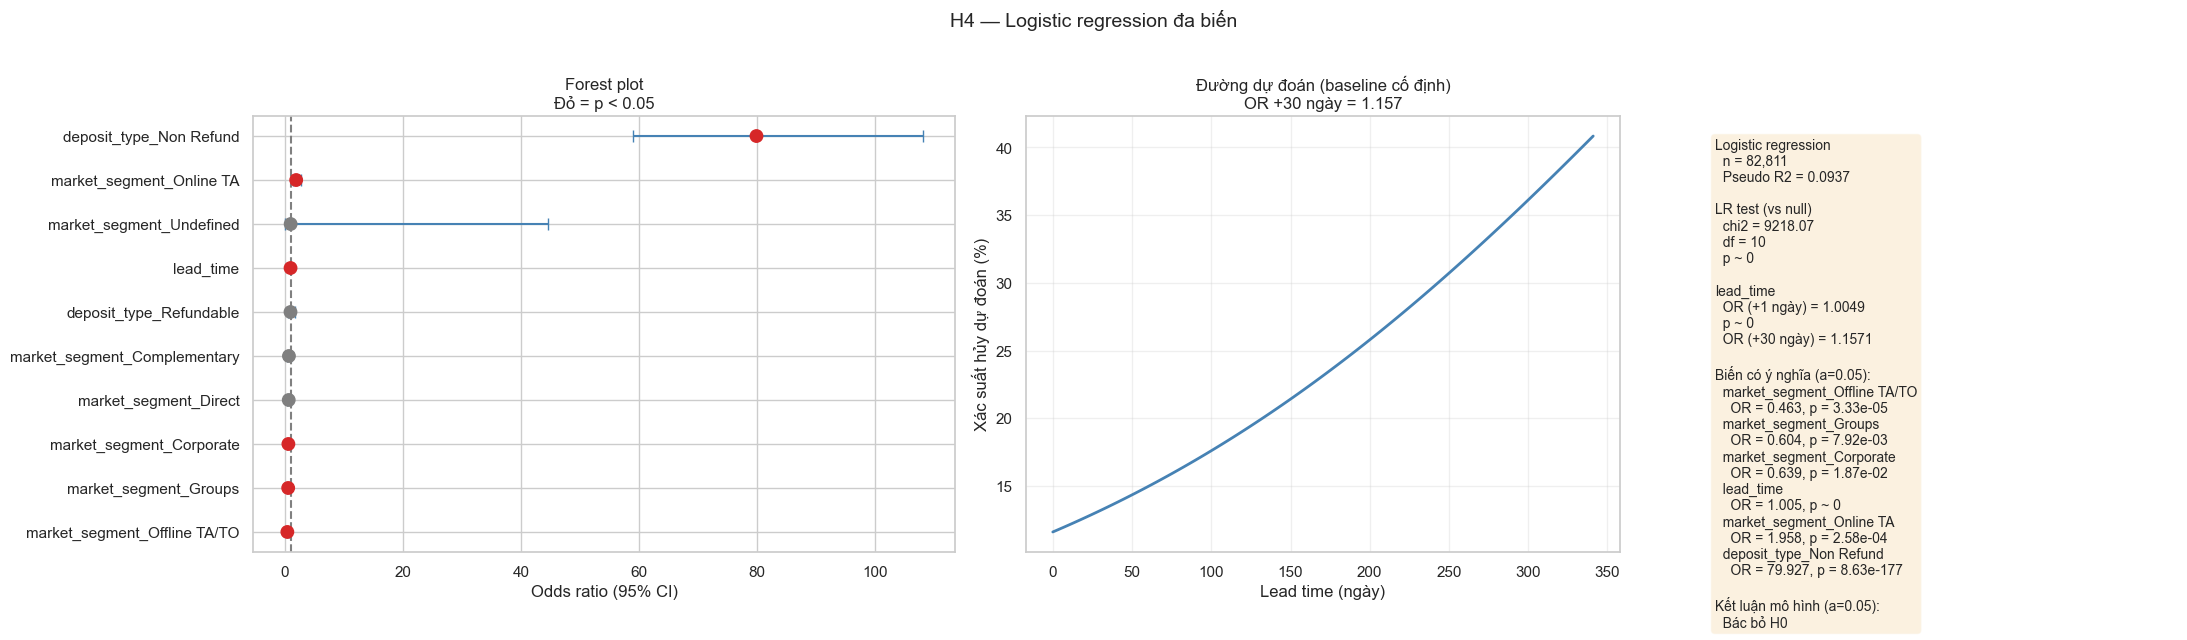

In [7]:
import statsmodels.api as sm

model_df = df[["is_canceled", "lead_time", "deposit_type", "market_segment"]].copy()

X_cat = pd.get_dummies(
    model_df[["deposit_type", "market_segment"]],
    drop_first=True,
)
X = pd.concat([model_df[["lead_time"]], X_cat], axis=1).astype(float)
X = sm.add_constant(X)
y = model_df["is_canceled"].astype(float)

logit = sm.Logit(y, X).fit(disp=False, maxiter=500, method="lbfgs")
print(logit.summary())

# Odds ratio + 95% CI
conf = logit.conf_int()
or_table = pd.DataFrame(
    {
        "coef": logit.params,
        "std_err": logit.bse,
        "z": logit.tvalues,
        "p_value": logit.pvalues,
        "odds_ratio": np.exp(logit.params),
        "or_ci_low": np.exp(conf[0]),
        "or_ci_high": np.exp(conf[1]),
    }
).sort_values("p_value")
or_table_display = or_table.drop(index="const", errors="ignore")
print("\nOdds ratio (baseline: No Deposit, Direct; lead_time = +1 ngày):")
display(or_table_display.round(4))

# OR theo +30 ngày lead_time (dễ diễn giải hơn)
if "lead_time" in logit.params.index:
    beta_lt = logit.params["lead_time"]
    or_30d = np.exp(beta_lt * 30)
    ci_30d = np.exp(conf.loc["lead_time"] * 30)
    print(f"\nLead time — OR cho +30 ngày: {or_30d:.4f} [{ci_30d[0]:.4f}, {ci_30d[1]:.4f}]")

# Null model: chỉ intercept (không dùng cột toàn 0 — sẽ gây singular matrix)
X_null = np.ones((len(y), 1))
null_model = sm.Logit(y, X_null).fit(disp=False, maxiter=500, method="lbfgs")
lr_stat = 2 * (logit.llf - null_model.llf)
lr_df = len(logit.params) - len(null_model.params)
lr_p = stats.chi2.sf(lr_stat, lr_df)
print(f"\nLikelihood Ratio Test (mô hình đầy đủ vs null):")
print(f"  LR chi2 = {lr_stat:.2f}, df = {lr_df}, p = {lr_p:.2e}")
print(f"  Pseudo R² (McFadden): {logit.prsquared:.4f}")

h4_result = {
    "lr_chi2": float(lr_stat),
    "lr_df": int(lr_df),
    "lr_p_value": float(lr_p),
    "pseudo_r2": float(logit.prsquared),
    "n_obs": int(logit.nobs),
    "lead_time_or_per_30d": float(or_30d) if "lead_time" in logit.params.index else None,
    "significant_predictors": or_table_display[or_table_display["p_value"] < ALPHA]
    .index.tolist(),
}

or_30d_val = float(or_30d) if "lead_time" in logit.params.index else None
plot_logistic_viz(
    logit, or_table_display, model_df,
    test_result=h4_result,
    lead_time_or_30d=or_30d_val,
)

## Dashboard tổng hợp — Effect size tất cả kiểm định

So sánh trực quan mức độ ảnh hưởng của từng test (không so sánh trực tiếp đơn vị khác nhau, chỉ để ranking tương đối).

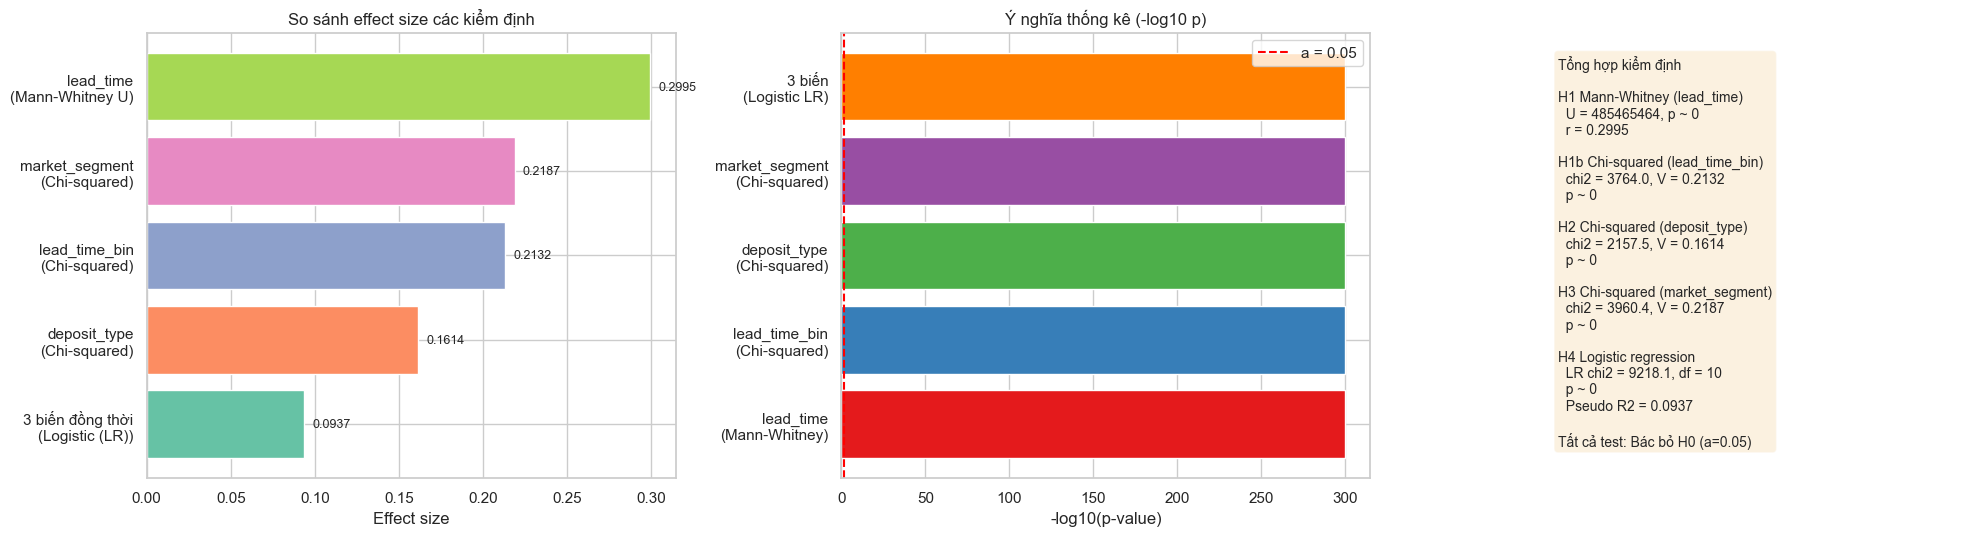

In [8]:
effect_rows = [
    {
        "test": "Mann-Whitney U",
        "biến": "lead_time",
        "metric": "|rank-biserial r|",
        "value": abs(h1_result["rank_biserial_r"]),
    },
    {
        "test": "Chi-squared",
        "biến": "lead_time_bin",
        "metric": "Cramér's V",
        "value": h1b_result["cramers_v"],
    },
    {
        "test": "Chi-squared",
        "biến": "deposit_type",
        "metric": "Cramér's V",
        "value": h2_result["cramers_v"],
    },
    {
        "test": "Chi-squared",
        "biến": "market_segment",
        "metric": "Cramér's V",
        "value": h3_result["cramers_v"],
    },
    {
        "test": "Logistic (LR)",
        "biến": "3 biến đồng thời",
        "metric": "Pseudo R²",
        "value": h4_result["pseudo_r2"],
    },
]
effect_df = pd.DataFrame(effect_rows).sort_values("value", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), gridspec_kw={"width_ratios": [1.2, 1.2, 1]})

colors = sns.color_palette("Set2", len(effect_df))
axes[0].barh(effect_df["biến"] + "\n(" + effect_df["test"] + ")", effect_df["value"], color=colors)
axes[0].set_xlabel("Effect size")
axes[0].set_title("So sánh effect size các kiểm định")
for y, (_, row) in enumerate(effect_df.iterrows()):
    axes[0].text(row["value"] + 0.005, y, f"{row['value']:.4f}", va="center", fontsize=9)

pvals = pd.DataFrame(
    [
        {"biến": "lead_time", "test": "Mann-Whitney", "p_value": h1_result["p_value"]},
        {"biến": "lead_time_bin", "test": "Chi-squared", "p_value": h1b_result["p_value"]},
        {"biến": "deposit_type", "test": "Chi-squared", "p_value": h2_result["p_value"]},
        {"biến": "market_segment", "test": "Chi-squared", "p_value": h3_result["p_value"]},
        {"biến": "3 biến", "test": "Logistic LR", "p_value": h4_result["lr_p_value"]},
    ]
)
pvals["neg_log10_p"] = -np.log10(pvals["p_value"].clip(lower=1e-300))
pvals = pvals.sort_values("neg_log10_p")
axes[1].barh(pvals["biến"] + "\n(" + pvals["test"] + ")", pvals["neg_log10_p"], color=sns.color_palette("Set1", len(pvals)))
axes[1].axvline(-np.log10(ALPHA), ls="--", color="red", label=f"a = {ALPHA}")
axes[1].set_xlabel("-log10(p-value)")
axes[1].set_title("Ý nghĩa thống kê (-log10 p)")
axes[1].legend()

summary_txt = (
    "Tổng hợp kiểm định\n\n"
    f"H1 Mann-Whitney (lead_time)\n"
    f"  U = {h1_result['u_stat']:.0f}, {_format_p(h1_result['p_value'])}\n"
    f"  r = {h1_result['rank_biserial_r']:.4f}\n\n"
    f"H1b Chi-squared (lead_time_bin)\n"
    f"  chi2 = {h1b_result['chi2']:.1f}, V = {h1b_result['cramers_v']:.4f}\n"
    f"  {_format_p(h1b_result['p_value'])}\n\n"
    f"H2 Chi-squared (deposit_type)\n"
    f"  chi2 = {h2_result['chi2']:.1f}, V = {h2_result['cramers_v']:.4f}\n"
    f"  {_format_p(h2_result['p_value'])}\n\n"
    f"H3 Chi-squared (market_segment)\n"
    f"  chi2 = {h3_result['chi2']:.1f}, V = {h3_result['cramers_v']:.4f}\n"
    f"  {_format_p(h3_result['p_value'])}\n\n"
    f"H4 Logistic regression\n"
    f"  LR chi2 = {h4_result['lr_chi2']:.1f}, df = {h4_result['lr_df']}\n"
    f"  {_format_p(h4_result['lr_p_value'])}\n"
    f"  Pseudo R² = {h4_result['pseudo_r2']:.4f}\n\n"
    f"Tất cả test: Bác bỏ H₀ (α={ALPHA})"
)
_stats_textbox(axes[2], summary_txt, fontsize=10)

plt.tight_layout()
plt.show()

## Tổng hợp kết quả kiểm định

In [9]:
summary = pd.DataFrame(
    [
        {
            "biến": "lead_time",
            "test": "Mann-Whitney U",
            "p_value": h1_result["p_value"],
            "effect_size": f"rank-biserial r = {h1_result['rank_biserial_r']:.4f}",
            "kết luận (α=0.05)": "Bác bỏ H₀" if h1_result["reject_h0"] else "Không bác bỏ H₀",
        },
        {
            "biến": "lead_time_bin",
            "test": "Chi-squared",
            "p_value": h1b_result["p_value"],
            "effect_size": f"Cramér's V = {h1b_result['cramers_v']:.4f}",
            "kết luận (α=0.05)": "Bác bỏ H₀" if h1b_result["reject_h0"] else "Không bác bỏ H₀",
        },
        {
            "biến": "deposit_type",
            "test": "Chi-squared",
            "p_value": h2_result["p_value"],
            "effect_size": f"Cramér's V = {h2_result['cramers_v']:.4f}",
            "kết luận (α=0.05)": "Bác bỏ H₀" if h2_result["reject_h0"] else "Không bác bỏ H₀",
        },
        {
            "biến": "market_segment",
            "test": "Chi-squared",
            "p_value": h3_result["p_value"],
            "effect_size": f"Cramér's V = {h3_result['cramers_v']:.4f}",
            "kết luận (α=0.05)": "Bác bỏ H₀" if h3_result["reject_h0"] else "Không bác bỏ H₀",
        },
        {
            "biến": "3 biến (đa biến)",
            "test": "Logistic regression (LR test)",
            "p_value": h4_result["lr_p_value"],
            "effect_size": f"Pseudo R² = {h4_result['pseudo_r2']:.4f}",
            "kết luận (α=0.05)": "Bác bỏ H₀" if h4_result["lr_p_value"] < ALPHA else "Không bác bỏ H₀",
        },
    ]
)
display(summary.style.format({"p_value": "{:.2e}"}))

print(f"\nBiến có ý nghĩa trong mô hình logistic (p < {ALPHA}):")
print(", ".join(h4_result["significant_predictors"]) or "(không có)")

,biến,test,p_value,effect_size,kết luận (α=0.05)
0,lead_time,Mann-Whitney U,0.00e+00,rank-biserial r = 0.2995,Bác bỏ H₀
1,lead_time_bin,Chi-squared,0.00e+00,Cramér's V = 0.2132,Bác bỏ H₀
2,deposit_type,Chi-squared,0.00e+00,Cramér's V = 0.1614,Bác bỏ H₀
3,market_segment,Chi-squared,0.00e+00,Cramér's V = 0.2187,Bác bỏ H₀
4,3 biến (đa biến),Logistic regression (LR test),0.00e+00,Pseudo R² = 0.0937,Bác bỏ H₀



Biến có ý nghĩa trong mô hình logistic (p < 0.05):
lead_time, deposit_type_Non Refund, market_segment_Offline TA/TO, market_segment_Online TA, market_segment_Groups, market_segment_Corporate
